In [24]:
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import pyogrio

from pyogrio import list_layers


# Maps for stylized facts about the Danish housing market
This notebook compiles maps of house prices and urabn densities across Danish postal codes from 1992 to 2024. The data is from the Central Register of Buildings and Dwellings of Denmark (BBR) and the Finance Denmark BM011 database.



### BBR data
First, the BBR-data is inspected:

In [25]:
import pyogrio


#see column names
pyogrio.read_info("DK_INSPIRE_BBR.gpkg")

/var/folders/nw/4t6rm3rn4r705nf30vzcz1xw0000gn/T/ipykernel_8190/3632772507.py:5: UserWarning: More than one layer found in 'DK_INSPIRE_BBR.gpkg': 'building' (default), 'otherConstruction'. Specify layer parameter to avoid this warning.
  pyogrio.read_info("DK_INSPIRE_BBR.gpkg")


{'layer_name': 'building',
 'crs': 'EPSG:25832',
 'encoding': 'UTF-8',
 'fields': array(['addressRepresentation', 'beginLifeSpanVersion', 'buildingNature',
        'conditionOfConstruction', 'connectionToElectricity',
        'connectionToGas', 'connectionToSewage', 'connectionToWater',
        'currentUse', 'dateOfConstruction_dateOfEvent_anyPoint',
        'dateOfConstruction_dateOfEvent_begin',
        'dateOfConstruction_dateOfEvent_end', 'dateOfDemolition',
        'dateOfRenovation_dateOfEvent_anyPoint',
        'dateOfRenovation_dateOfEvent_begin',
        'dateOfRenovation_dateOfEvent_end', 'document', 'elevation',
        'endLifeSpanVersion', 'energyPerformance',
        'externalReference_reference1', 'externalReference_reference2',
        'externalReference_system1', 'externalReference_system2',
        'externalReference_systemName1', 'externalReference_systemName2',
        'floorDescription_floorRange', 'floorDescription',
        'geometry_horizontalAccuracy', 'geometr

The necessary observations of the BBR register are loaded (takes around 10 minutes to finish):

In [26]:

_file = "DK_INSPIRE_BBR.gpkg"
_layer = list_layers(_file)[0][0]
bbr = gpd.read_file(
    _file, layer=_layer, engine="pyogrio",
    columns=['officialArea', 'addressRepresentation', 'dateOfConstruction_dateOfEvent_anyPoint', 'dateOfDemolition', 'currentUse', 'endLifeSpanVersion'],
)
#bbr = bbr_full.sample(n=10_000, random_state=42)

print(bbr.info())

# officialArea can arrive as strings — coerce to numeric
bbr['officialArea'] = pd.to_numeric(bbr['officialArea'], errors='coerce')



<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 5635776 entries, 0 to 5635775
Data columns (total 7 columns):
 #   Column                                   Dtype   
---  ------                                   -----   
 0   addressRepresentation                    object  
 1   currentUse                               object  
 2   dateOfConstruction_dateOfEvent_anyPoint  object  
 3   dateOfDemolition                         object  
 4   endLifeSpanVersion                       object  
 5   officialArea                             object  
 6   geometry                                 geometry
dtypes: geometry(1), object(6)
memory usage: 301.0+ MB
None


The data matches Statistics Denmark BYGB12 database quite well, but not entirely. Number of buildings in Denmark in 2024 is 4 870 131, while the BBR dataset counts 4 985 242 buildings built before 2025:

In [27]:

# Parse construction date and count by cutoff year
construction = pd.to_datetime(
    bbr['dateOfConstruction_dateOfEvent_anyPoint'], errors='coerce'
)

total        = len(bbr)
has_date     = construction.notna().sum()
before_1992  = (construction.dt.year < 1993).sum()
before_2024  = (construction.dt.year < 2025).sum()

print(f"Total rows:                {total:>10,}")
print(f"Has construction date:     {has_date:>10,}  ({100*has_date/total:.1f}%)")
print(f"Built before and including 1992:         {before_1992:>10,}  ({100*before_1992/total:.1f}%)")
print(f"Built before and including 2024:         {before_2024:>10,}  ({100*before_2024/total:.1f}%)")


Total rows:                 5,635,776
Has construction date:      5,022,618  (89.1%)
Built before and including 1992:          3,381,113  (60.0%)
Built before and including 2024:          4,985,242  (88.5%)


Then the entire building mass can be summed across postal codes by extracting the postal code from addresRepresentation.

In [28]:
# ── 1. Extract 4-digit postal code from addressRepresentation ─────────────────
bbr['postalcode'] = (
    bbr['addressRepresentation']
    .astype(str)
    .str.extract(r'\b(\d{4})\b', expand=False)
)

# ── 2. Sum officialArea by postal code ────────────────────────────────────────
area_by_zip = (
    bbr.dropna(subset=['postalcode', 'officialArea'])
    .groupby('postalcode', as_index=False)['officialArea']
    .sum()
    .rename(columns={'officialArea': 'total_footprint_m2'})
)


# ── 3. Define Footprint stocks in 1992 and 2024 ─────────────────────────────────────────
construction = pd.to_datetime(
    bbr['dateOfConstruction_dateOfEvent_anyPoint'], errors='coerce'
)
bbr_work = bbr.copy()
bbr_work['year_built'] = construction.dt.year
bbr_work['postalcode'] = (
    bbr_work['addressRepresentation']
    .astype(str)
    .str.extract(r'\b(\d{4})\b', expand=False)
)
bbr_work['officialArea'] = pd.to_numeric(bbr_work['officialArea'], errors='coerce')

def footprint_stock(cutoff_year):
    return (
        bbr_work[bbr_work['year_built'] < cutoff_year]
        .dropna(subset=['postalcode', 'officialArea'])
        .groupby('postalcode', as_index=False)['officialArea']
        .sum()
    )

fp1992 = footprint_stock(1993).rename(columns={'officialArea': 'fp_1992'})
fp2024 = footprint_stock(2025).rename(columns={'officialArea': 'fp_2024'})


### Postal code polygons from Larsen (2024)
Data to print maps of the postal code areas are from Larsen (2024). I load the geojson file here:

In [29]:

# ── 1. Load postal code polygons ──────────────────────────────────────────────
postal_url = (
    "https://raw.githubusercontent.com/magnuslarsen/"
    "geoJSON-Danish-municipalities/master/postal_codes/postal_codes.geojson"
)
postal = gpd.read_file(postal_url)

# ── 2. Auto-detect the postal code column (4-digit numeric strings) ───────────────
pc_col = next(
    (c for c in postal.columns
     if postal[c].dropna().astype(str).str.match(r'^\d{4}$').mean() > 0.8),
    None
)
if pc_col is None:
    raise ValueError(f"Cannot find postal code column. Available: {postal.columns.tolist()}")

# ── 3. Merge footprint totals into polygon GDF ────────────────────────────────
postal = postal.merge(
    area_by_zip,
    left_on=pc_col,
    right_on='postalcode',
    how='left'
)
postal['total_footprint_m2'] = pd.to_numeric(
    postal['total_footprint_m2'], errors='coerce'
).fillna(0)


### Price data from Finance Denmark
Price data is from Finance Denmark's BM011 data base:

In [30]:
raw = pd.read_excel('prices_postalcode.xlsx', header=None)
raw.columns = ['label', 'price_1992', 'price_2024']
raw = raw.iloc[1:].reset_index(drop=True)

def expand_row(row):
    label = str(row['label']).strip()
    m = re.match(r'^(\d{4})-(\d{4})', label)
    if m:
        lo, hi = int(m.group(1)), int(m.group(2))
        return [(f'{pc:04d}', row['price_1992'], row['price_2024'])
                for pc in range(lo, hi + 1)]
    m2 = re.match(r'^(\d{4})', label)
    if m2:
        return [(m2.group(1), row['price_1992'], row['price_2024'])]
    return []

records = []
for _, r in raw.iterrows():
    records.extend(expand_row(r))

prices = pd.DataFrame(records, columns=['postalcode', 'price_1992', 'price_2024'])
prices['price_1992'] = pd.to_numeric(prices['price_1992'], errors='coerce')
prices['price_2024'] = pd.to_numeric(prices['price_2024'], errors='coerce')
prices['price_pct'] = (prices['price_2024'] / prices['price_1992'] - 1) * 100

### Data merging to produce figure 2.2 and 2.3

In [45]:



# Drop any columns carried over from a previous run of this cell
postal = postal.drop(columns=['postalcode', 'price_1992', 'price_2024', 'price_pct',
                               'fp_1992', 'fp_2024', 'zone_area_m2',
                               'density_1992', 'density_2024', 'density_pct'], errors='ignore')

postal = (postal
    .merge(prices[['postalcode', 'price_1992', 'price_2024', 'price_pct']], left_on=pc_col, right_on='postalcode', how='left')
    .drop(columns=['postalcode'], errors='ignore')
    .merge(fp1992.rename(columns={'officialArea': 'fp_1992'})[['postalcode', 'fp_1992']], left_on=pc_col, right_on='postalcode', how='left')
    .drop(columns=['postalcode'], errors='ignore')
    .merge(fp2024.rename(columns={'officialArea': 'fp_2024'})[['postalcode', 'fp_2024']], left_on=pc_col, right_on='postalcode', how='left')
    .drop(columns=['postalcode'], errors='ignore')
)
# Compute polygon area in m² by reprojecting to a metric CRS (UTM zone 32N, suitable for Denmark)
postal['zone_area_m2'] = postal.to_crs(epsg=25832).geometry.area

postal['density_1992'] = postal['fp_1992'] / (postal['zone_area_m2'])
postal['density_2024'] = postal['fp_2024'] / (postal['zone_area_m2'])
postal['density_pct'] = np.where(
    postal['density_1992'] > 0,
    (postal['density_2024'] / postal['density_1992'] - 1) * 100,
    np.nan
)



In [46]:
print(postal['density_2024'].describe())

count    797.000000
mean       4.111779
std       22.171709
min        0.002140
25%        0.009868
50%        0.017161
75%        0.169072
max      382.009037
Name: density_2024, dtype: float64


Plotting densities and square meter prices in 2024 (figure 2.2)

/var/folders/nw/4t6rm3rn4r705nf30vzcz1xw0000gn/T/ipykernel_8190/189745893.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


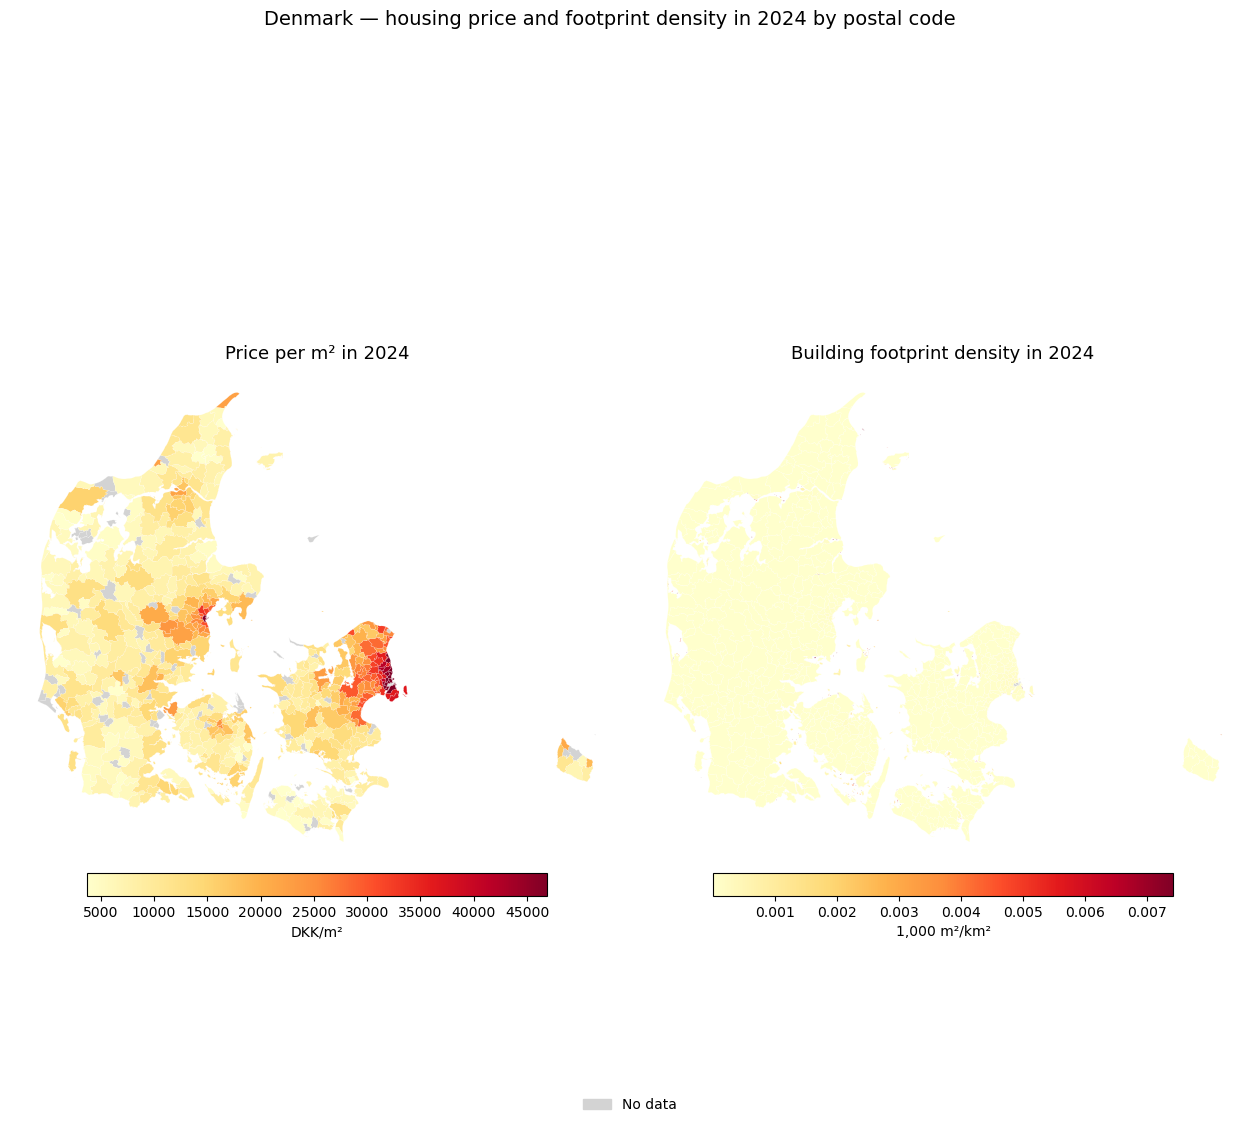

In [47]:

# ── 1. Choropleth helper ──────────────────────────────────────────────────────
def choropleth(ax, gdf, col, title, cmap='RdYlGn_r', unit='%', scale=1.0,
               vmin_q=0.02, vmax_q=0.98):
    vals  = gdf[col].dropna() * scale
    vmin  = vals.quantile(vmin_q)
    vmax  = vals.quantile(vmax_q)
    norm  = Normalize(vmin=vmin, vmax=vmax)
    sm    = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    valid = gdf[col].notna()
    gdf[~valid].plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.1)

    # Build a temporary series with the scaled values for plotting
    scaled_col = '_scaled_' + col
    gdf_plot = gdf.assign(**{scaled_col: gdf[col] * scale})
    gdf_plot[valid].plot(ax=ax, column=scaled_col, cmap=cmap, norm=norm,
                         edgecolor='white', linewidth=0.1)

    plt.colorbar(sm, ax=ax, orientation='horizontal', location='bottom',
                 shrink=0.75, label=unit, pad=0.01)
    ax.set_title(title, fontsize=13, pad=8)
    ax.axis('off')

# ── 2. Draw ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 11),
                         gridspec_kw={'wspace': 0.02})

choropleth(axes[0], postal, 'price_2024',
           'Price per m\u00b2 in 2024',
           cmap='YlOrRd', unit='DKK/m\u00b2')

choropleth(axes[1], postal, 'density_2024',
           'Building footprint density in 2024',
           cmap='YlOrRd', unit='1,000 m\u00b2/km\u00b2', scale=1e-3, vmax_q=0.90)

grey_patch = mpatches.Patch(color='lightgrey', label='No data')
fig.legend(handles=[grey_patch], loc='lower center', fontsize=10, frameon=False)
fig.suptitle('Denmark \u2014 housing price and footprint density in 2024 by postal code',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


Plotting changes from 1992 to 2024 (figure 2.3)

In [1]:

# ── 2. Draw ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 11),
                         gridspec_kw={'wspace': 0.02})

choropleth(axes[0], postal, 'price_pct',
           'Price per m\u00b2 change 1992 \u2192 2024 (%)')
choropleth(axes[1], postal, 'density_pct',
           'Building footprint density change 1992 \u2192 2024 (%)')

grey_patch = mpatches.Patch(color='lightgrey', label='No data')
fig.legend(handles=[grey_patch], loc='lower center', fontsize=10, frameon=False)
fig.suptitle('Denmark \u2014 housing price and footprint density changes by postal code',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


NameError: name 'plt' is not defined

In [ ]:
# ── 6. Draw ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 11),
                         gridspec_kw={'wspace': 0.02})

choropleth(axes[0], postal, 'price_pct',
           'Price per m\u00b2 change 1992 \u2192 2024 (%)')
choropleth(axes[1], postal, 'density_2024',
           'Building density \u2192 2024 ()')

grey_patch = mpatches.Patch(color='lightgrey', label='No data')
fig.legend(handles=[grey_patch], loc='lower center', fontsize=10, frameon=False)
fig.suptitle('Denmark \u2014 housing price and footprint density changes by postal code',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()